# Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

# Read from file

In [39]:
#df = pd.read_csv('database/raingauge_data_2023_2025.csv')
df = pd.read_csv('database/raingauge_nea_data/2025/weather_station_data_2025.csv')

In [4]:
df

,timestamp,stationId,value
0,2025-01-01T00:00:00+08:00,S230,0.0
1,2025-01-01T00:00:00+08:00,S94,0.0
2,2025-01-01T00:00:00+08:00,S50,0.0
3,2025-01-01T00:00:00+08:00,S209,0.0
4,2025-01-01T00:00:00+08:00,S92,0.0
...,...,...,...
6109013,2025-12-31T23:55:00+08:00,S64,0.0
6109014,2025-12-31T23:55:00+08:00,S60,0.0
6109015,2025-12-31T23:55:00+08:00,S113,0.0
6109016,2025-12-31T23:55:00+08:00,S117,0.0


# Data preparation

In [5]:
#Check duplicate rows
df.loc[df.duplicated()]

,timestamp,stationId,value


In [6]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
timestamps = df['timestamp'].copy()
timestamps = timestamps.drop_duplicates()

In [7]:
full_range = pd.date_range(
    start = df['timestamp'].min(),
    end = df['timestamp'].max(),
    freq='5min',
)

difference = full_range.difference(timestamps)
print("--------DIFFERECE---------")
print(difference)

print("===========")
missing_dates = set(difference.normalize())
print(missing_dates)
date_strings = [d.strftime('%Y-%m-%d') for d in missing_dates]
print(date_strings)

--------DIFFERECE---------
DatetimeIndex(['2025-01-20 18:20:00+08:00', '2025-01-20 18:25:00+08:00',
               '2025-01-20 18:30:00+08:00', '2025-01-20 18:35:00+08:00',
               '2025-01-20 18:40:00+08:00', '2025-01-20 18:45:00+08:00',
               '2025-01-20 18:50:00+08:00', '2025-01-20 18:55:00+08:00',
               '2025-01-20 19:00:00+08:00', '2025-01-20 19:05:00+08:00',
               ...
               '2025-11-18 21:05:00+08:00', '2025-11-18 21:10:00+08:00',
               '2025-11-18 21:15:00+08:00', '2025-11-18 21:20:00+08:00',
               '2025-11-18 21:25:00+08:00', '2025-11-18 21:30:00+08:00',
               '2025-11-18 21:35:00+08:00', '2025-11-18 21:40:00+08:00',
               '2025-11-18 21:45:00+08:00', '2025-11-18 21:50:00+08:00'],
              dtype='datetime64[ns, UTC+08:00]', length=360, freq=None)
{Timestamp('2025-09-13 00:00:00+0800', tz='UTC+08:00'), Timestamp('2025-11-18 00:00:00+0800', tz='UTC+08:00'), Timestamp('2025-05-29 00:00:00+0800', tz

# Get uptime of sensors

In [40]:
#Find the uptime of sensors

pivot_df = pd.pivot(df, index="timestamp", columns="stationId", values ="value")
stats_df = pivot_df.count()
max = stats_df.max()
stats_df = stats_df/max
stats_df
stats_df.to_csv("view.csv")
total_count = stats_df.shape[0]
usable_count = stats_df[stats_df >= 0.9].shape[0]

print(f"Total_count {total_count}")
print(f"Usable count: {usable_count}")

Total_count 67
Usable count: 53


# Get number of events
Each event will be split when there is a break of 12 hours between rainfall events. That will categorise a rainfall event. We will keep the 1 hour leading up to the next event as well as the 1 hour after that event

In [ ]:
#Get the number of non-zero rainfall sensor values in the dataframe
timestamp_count_df = pivot_df.fillna(0)
timestamp_count_df = (timestamp_count_df != 0).sum(axis=1)

#Get the number of consecuitive 0s in the resulting df
is_zero = timestamp_count_df == 0
print(is_zero)

groups = (is_zero != is_zero.shift()).cumsum()

zero_sequences = timestamp_count_df.groupby(groups).size()
print(zero_sequences > )
timestamp_count_df

timestamp
2025-01-01 00:00:00+08:00     True
2025-01-01 00:05:00+08:00    False
2025-01-01 00:10:00+08:00     True
2025-01-01 00:15:00+08:00     True
2025-01-01 00:20:00+08:00     True
                             ...  
2025-12-31 23:35:00+08:00     True
2025-12-31 23:40:00+08:00     True
2025-12-31 23:45:00+08:00     True
2025-12-31 23:50:00+08:00     True
2025-12-31 23:55:00+08:00     True
Length: 104760, dtype: bool
1        1
2        1
3        5
4        1
5        9
        ..
6593     3
6594     2
6595     2
6596    34
6597    34
Length: 6597, dtype: int64


timestamp
2025-01-01 00:00:00+08:00    0
2025-01-01 00:05:00+08:00    1
2025-01-01 00:10:00+08:00    0
2025-01-01 00:15:00+08:00    0
2025-01-01 00:20:00+08:00    0
                            ..
2025-12-31 23:35:00+08:00    0
2025-12-31 23:40:00+08:00    0
2025-12-31 23:45:00+08:00    0
2025-12-31 23:50:00+08:00    0
2025-12-31 23:55:00+08:00    0
Length: 104760, dtype: int64

In [14]:
#Fetch missing data

# from database.nea_data_fetch_v2 import get_weather_station_data

# date_list = date_strings
year=2024

# weather_station_data, stations = get_weather_station_data(start_time=None, end_time = None, sleep_sec=0, date_list=date_strings)
folder_path = f"database/raingauge_nea_data/2024"
weather_data_filename =f"{folder_path}/weather_station_data_{year}_refetch.csv"
station_locations_filename = f"{folder_path}/weather_stations_{year}_refetch.csv"
weather_station_data.to_csv(weather_data_filename, index=False)
stations.to_csv(station_locations_filename, index=False)
print(f"Saved weather data to {weather_data_filename}")
print(f"Saved weather station locations to {station_locations_filename}")

Saved weather data to database/raingauge_nea_data/2024/weather_station_data_2024_refetch.csv
Saved weather station locations to database/raingauge_nea_data/2024/weather_stations_2024_refetch.csv


In [ ]:
missing_timestamps = []
for date in date_list: 
  print(date)
  missing_range=pd.date_range(
    start=date,
    end=date,
    freq='5min',
    inclusive="both"
  )
  print(missing_range)
  missing_timestamps.append(missing_range)

print(missing_timestamps)

In [ ]:
import requests
from datetime import datetime
URL = "https://api-open.data.gov.sg/v2/real-time/api/rainfall"
cur_date = f"2023-1-10"
cur_date = datetime.strptime(cur_date, "%Y-%m-%d").date()
cur_date = pd.date_range(start=cur_date, end=cur_date, freq='D')
response = requests.get(
    URL, params={"date": cur_date[0].date()}, timeout=100
)

#Get first page of the day

df = pd.DataFrame((response.json()['data']['readings']))
df_list = [df]
pagination_token = response.json()['data']['paginationToken']

stations = pd.DataFrame(response.json()['data']['stations'])
stations[['latitude', 'longitude']] = stations['location'].apply(pd.Series)
stations = stations.drop('location', axis=1)
print(stations)

#Get subsequent pages
# while pagination_token:
#     response = requests.get(
#         URL, params={"date": cur_date[0].date(), "paginationToken": pagination_token}, timeout=100
#     )
#     page_df = pd.DataFrame((response.json()['data']['readings']))
#     if 'paginationToken' in response.json()['data'].keys():
#         pagination_token = response.json()['data']['paginationToken']
#     else:
#         pagination_token = None
#     df_list.append(page_df)

#Concat all the pages at the end to get a full df
df = pd.concat(df_list, ignore_index=True)
df_clean = pd.concat(
    [df.drop(columns="data"), df["data"].explode().apply(pd.Series)], axis=1
)
response.raise_for_status()


In [ ]:
print(df['data'].explode().apply(pd.Series))

df_clean = pd.concat(
            [df.drop(columns="data"), df["data"].explode().apply(pd.Series)], axis=1
            )

df_clean

In [31]:
#combine all excel files

dataframes = []
for year in range(2023, 2026):
  filepath = f'database/raingauge_nea_data/{year}/weather_station_data_{year}.csv'
  print(f"year {year} read")
  year_df = pd.read_csv(filepath)
  dataframes.append(year_df)

all_years_df = pd.concat(dataframes)

year 2023 read
year 2024 read
year 2025 read


In [32]:
all_years_df
all_years_df.to_csv("database/raingauge_data_2023_2025.csv")

In [21]:
timestamp_station_df = pd.pivot_table(all_years_df, index='timestamp', columns='stationId')

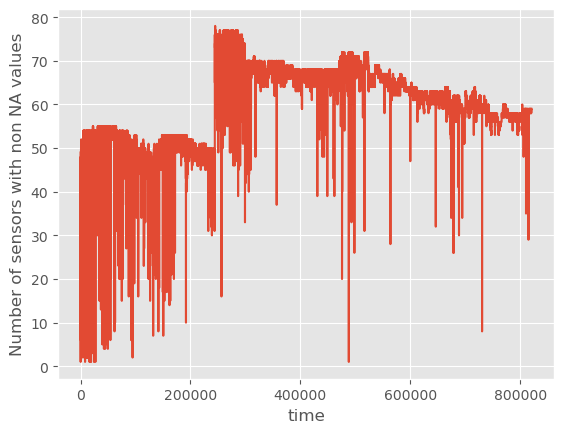

In [27]:
counts = timestamp_station_df.count(axis=1)
counts_list = counts.to_list()

plt.plot(counts_list)
plt.xlabel("time")
plt.ylabel("Number of sensors with non NA values")
plt.show()